# Импорты

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split

from sklearn.preprocessing import StandardScaler

from sklearn.impute import SimpleImputer

from sklearn.cluster import KMeans, AgglomerativeClustering

from sklearn.metrics import silhouette_score

from scipy.cluster.hierarchy import dendrogram

# 2.3.1. Загрузка данных и первичный анализ (для каждого датасета)

### Загрузка

In [2]:
data = []
for i in range (1,4):
    data.append(pd.read_csv(f'data/S07-hw-dataset-0{i}.csv'))

### Описание

In [3]:
for df in data:
    print(f'Датасет:',
          f'Вид строк:\n{df.head()}',
          f'Информация:\n{df.info()}',
          f'Описание:\n{df.describe()}',
          f'Доля пропусков:\n{df.isna().mean()}', sep = '\n\n')

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 12000 entries, 0 to 11999
Data columns (total 9 columns):
 #   Column     Non-Null Count  Dtype  
---  ------     --------------  -----  
 0   sample_id  12000 non-null  int64  
 1   f01        12000 non-null  float64
 2   f02        12000 non-null  float64
 3   f03        12000 non-null  float64
 4   f04        12000 non-null  float64
 5   f05        12000 non-null  float64
 6   f06        12000 non-null  float64
 7   f07        12000 non-null  float64
 8   f08        12000 non-null  float64
dtypes: float64(8), int64(1)
memory usage: 843.9 KB
Датасет:

Вид строк:
   sample_id        f01        f02       f03         f04        f05  \
0          0  -0.536647 -69.812900 -0.002657   71.743147 -11.396498   
1          1  15.230731  52.727216 -1.273634 -104.123302  11.589643   
2          2  18.542693  77.317150 -1.321686 -111.946636  10.254346   
3          3 -12.538905 -41.709458  0.146474   16.322124   1.391137   
4          4  -6.903056 

### Разбиение

In [4]:
X_data = []
id_data = []
for df in data:
    id_data.append(df.iloc[:,1])
    X_data.append(df.iloc[:,1:])

# 2.3.2. Препроцессинг

In [5]:
# Масштабирование и Обработка пропусков
scaler = StandardScaler()
imputer = SimpleImputer(strategy='median')
for i in range(len(X_data)):
    X_data[i][:] = imputer.fit_transform(X_data[i][:])
    X_data[i] = scaler.fit_transform(X_data[i])

# 2.3.3. Модели недели 7 (для каждого датасета – минимум 2 алгоритма)

### KMeans 

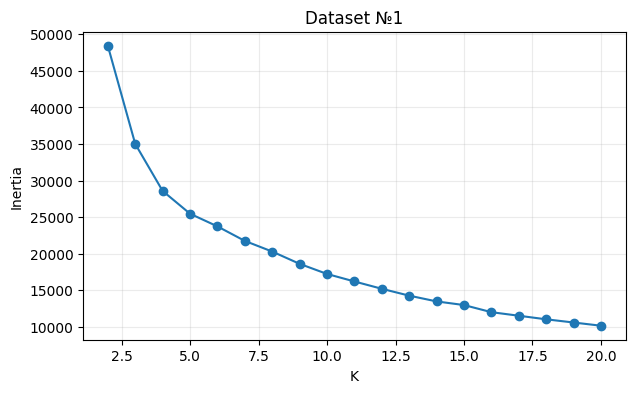

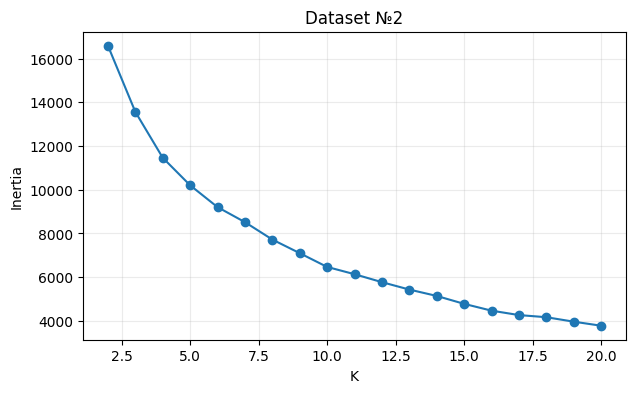

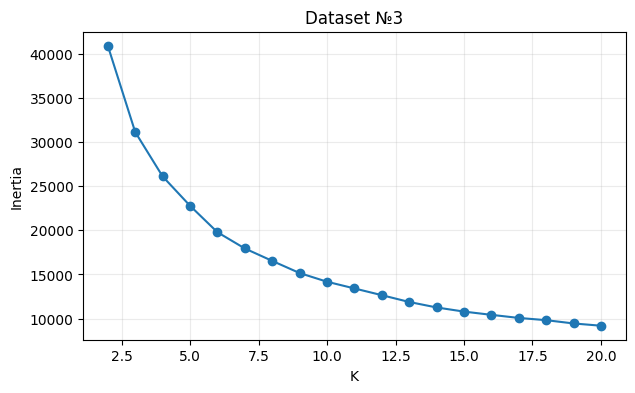

In [6]:
RS = 42
N_I = 5

k_values = range(2,21)
inertias_data = []

for i in range(3):
    inertias = []
    for k in k_values:
        m = KMeans(n_clusters = k, n_init = N_I, random_state = RS)
        labels = m.fit_predict(X_data[i])
        inertias.append(m.inertia_)
    inertias_data.append(inertias)

for i in range(3):
    plt.figure(figsize = (7,4))
    plt.plot(k_values, inertias_data[i], marker = 'o')
    plt.xlabel('K')
    plt.ylabel('Inertia')
    plt.title(f"Dataset №{i+1}")
    plt.grid(True, alpha=0.25)
    plt.show()

### AgglomerativeClustering 

In [10]:
linkages = ["single", "complete", "average", "ward"]
scores_data = []

for i in range(3):
    subset_idx = np.random.choice(len(X_data[i]), size=5000, replace=False) # индексы подвыборки
    subset = X_data[i][subset_idx]
    scores_by_dataset = {}
    for linkage in linkages:
        scores_by_linkage = []
        for k in k_values:
            model = AgglomerativeClustering(n_clusters=k, linkage=linkage)
            labels = model.fit_predict(subset)
            score = silhouette_score(subset, labels)
            scores_by_linkage.append(score)
        scores_by_dataset[linkage] = scores_by_linkage
    scores_data.append(scores_by_dataset)

print('scores calculated')

scores calculated


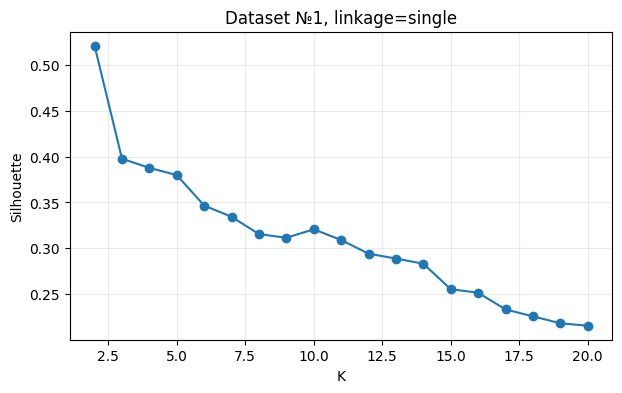

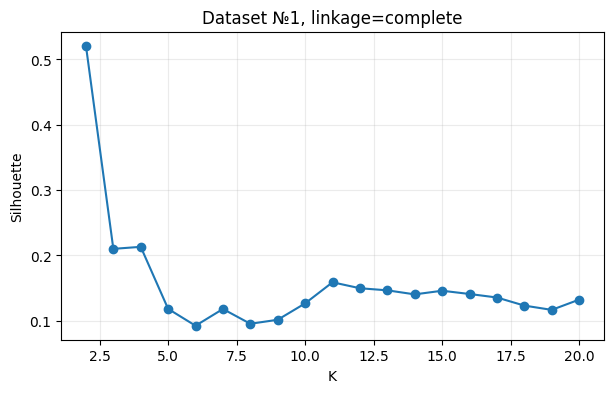

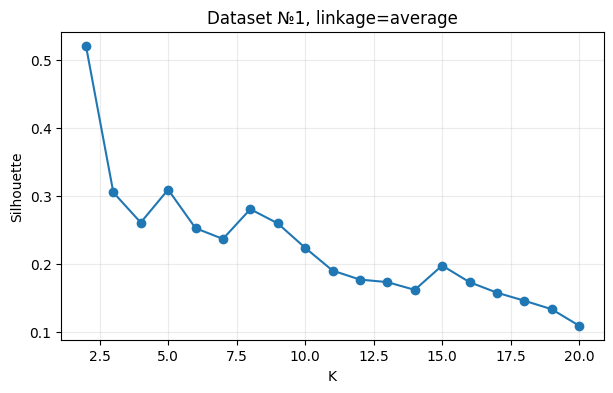

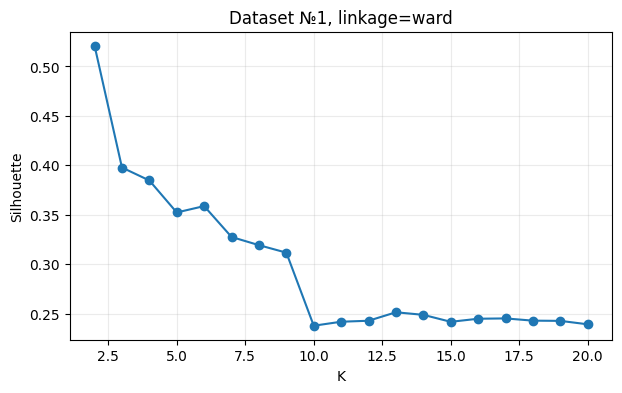

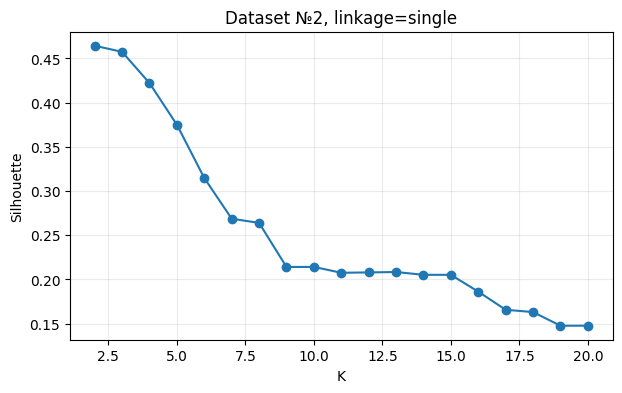

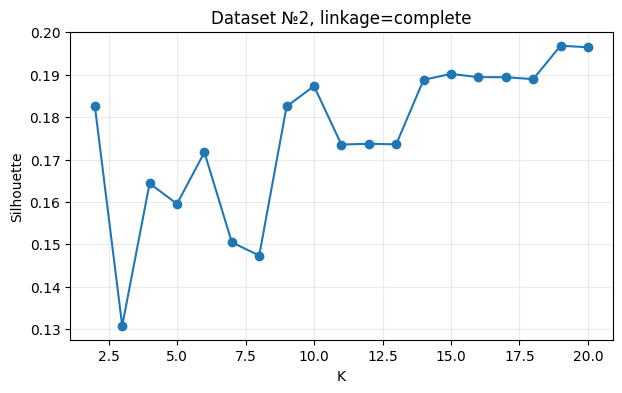

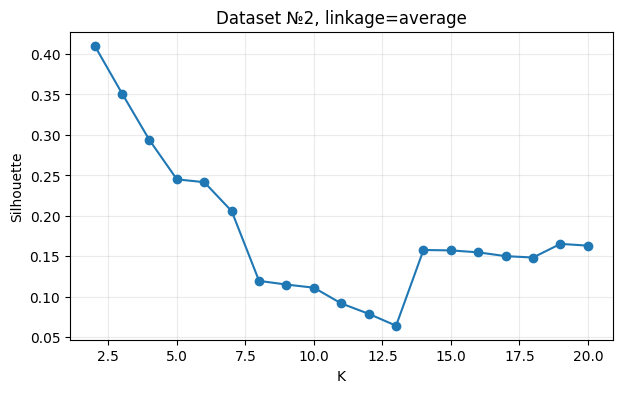

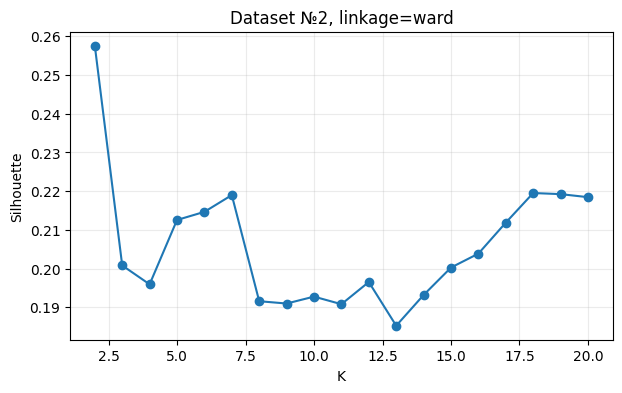

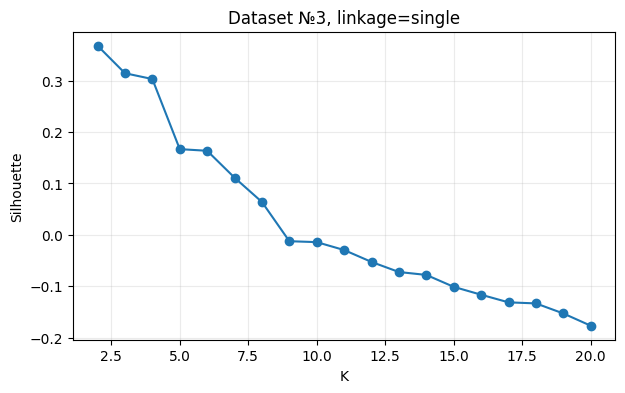

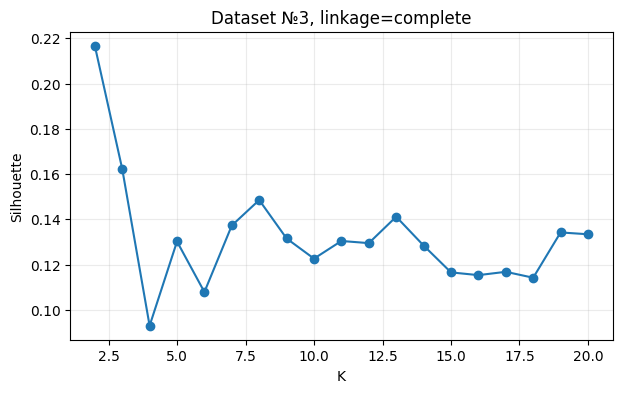

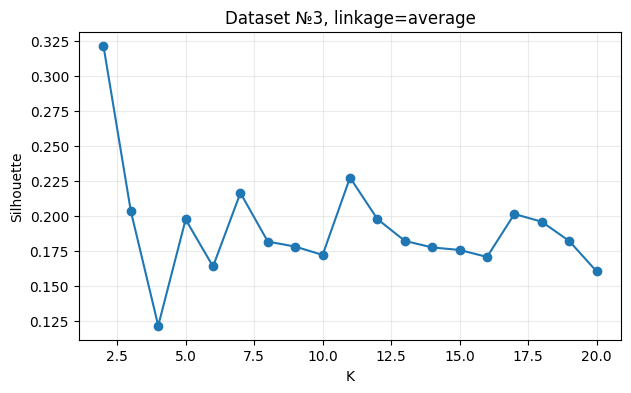

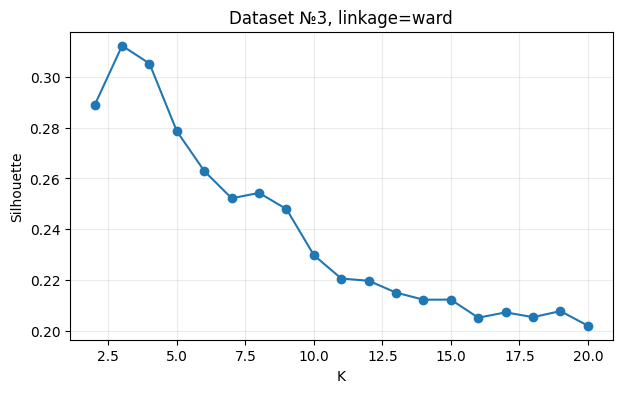

In [8]:
for i in range(3):
    for linkage in linkages:
        plt.figure(figsize = (7,4))
        plt.plot(k_values, scores_data[i][linkage], marker = 'o')
        plt.xlabel('K')
        plt.ylabel('Silhouette')
        plt.title(f"Dataset №{i+1}, linkage={linkage}")
        plt.grid(True, alpha=0.25)
        plt.show()

### Денрограммы

In [9]:
for i in range(3):
    for linkage in linkages:
        _ = plot_dendrogram(
            X_sub,
            method=method,
            truncate_mode=None,
            p=30,
            title = f"Dataset №{i+1}, linkage={linkage}"
        )

NameError: name 'plot_dendrogram' is not defined

### Выбор K для каждого датасета

In [ ]:
real_K = [] # ручной выбор на основе алгоритмов выше, особое внимание на денрограмму
best_linkages = []

### Выбор лучших моделей

In [ ]:
best_models_data = []
for i in range(3):
    km = KMeans(n_clusters = real_K[i], n_init = N_I, random_state = RS)
    ac = AgglomerativeClustering(n_clusters=k, linkage=best_linkages[i])
    best_models_data.append({
    {'KMeans': km},
    {'AgglomerativeClustering', ac}
    })

# 2.3.4. Метрики качества

### KMeans

### AgglomerativeClustering

# 2.3.5. Визуализация

# 2.3.6. Устойчивость

# 2.3.7. Итог по каждому датасету

# 2.4. Артефакты эксперимента